# Objetivo

Explorar cómo cambian las simulaciones de precios cuando se modifican los parámetros del modelo.

Deberás variar un parámetro a la vez, manteniendo los demás constantes (ceteris paribus) para entender cómo cada variable afecta el comportamiento del activo y el valor de la opción.

Usando el mismo activo que usamos, con los mismos parámetros usados en clase, también disponibles en Notion.

 

## Parámetros del modelo

Los parámetros que pueden modificar el precio de una opción son:

Parámetro	Significado
S0	Precio inicial del activo
K	Precio de ejercicio
σ	Volatilidad
r	Tasa libre de riesgo
T	Tiempo al vencimiento
N	Número de simulaciones


## Parte 1 — Volatilidad

Modificar únicamente σ.

Probar con:

σ = 0.01
σ = 0.10
σ = 0.20
σ = 0.40
Graficar:

Distribución del precio Spot final en los 4 escenarios
Crear:

- Crear una tabla con el valor de la call para cada escenario

- Crear una tabla con el valor de la put para cada escenario

## Preguntas

- ¿Qué sucede con la dispersión de las trayectorias?

- ¿Cómo cambia la distribución de precios?

- ¿Aumenta o disminuye el valor de la opción conforme aumenta sigma?

## Actividad 2 — Tiempo al vencimiento

Modificar únicamente T.

Probar con:

T = 30 días
T = 100 días
T = 1 año

Graficar nuevamente:


1. Distribución final del precio Spot

Crear nuevamente:

- Crear una tabla con el valor de la call para cada escenario

- Crear una tabla con el valor de la put para cada escenario

## Preguntas

- ¿Cómo cambia la distribución final del precio al aumentar T?

- ¿Aumenta o disminuye el valor de la opción conforme aumenta sigma?


## Actividad 3 — Precio de ejercicio

Modificar únicamente K.

Probar con:

K = S0 * 0.70
K = S0 * 0.90
K = S0
K = S0 * 1.10
K = S0 * 1.30
Crear:

- Crear una tabla con el valor de la call para cada escenario

- Crear una tabla con el valor de la put para cada escenario

## Preguntas

- ¿Aumenta o disminuye el valor de la opción conforme aumenta K?

- ¿Qué ocurre cuando el strike es relativamente muy alto? ¿Cuando es muy bajo?

## Actividad 4 — Tasa libre de riesgo

Modificar únicamente r.

Probar con:

r = 0.01
r = 0.05
r = 0.10

Graficar:
1. Distribución final del precio Spot

## Preguntas

- ¿Cómo cambia el crecimiento esperado del precio del activo?

- ¿Qué sucede con el valor de la call cuando aumenta la tasa libre de riesgo?

- ¿Qué sucede con el valor de la put cuando aumenta la tasa libre de riesgo?

## Entregable

Código en github o collab (link como comentario)

PDF con las respuestas y las gráficas 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from IPython.display import display
pd.options.display.float_format = '{:,.8f}'.format



In [2]:
# Descargamos los datos 

ticker = 'SPY'
data = yf.download(ticker, start='2022-01-01', end='2026-03-10')['Close']['SPY']
S0 = data.iloc[-1]

[*********************100%***********************]  1 of 1 completed


In [3]:
# Parámetros

r_base = 0.08
T_base = 100 / 365
K_base = 580
N = 10000

In [4]:
# Función general para simular y valuar 

def monte_carlo_sim(S0, K, T, r, sigma, N):
    Z = np.random.normal(0, 1, N)
    St = S0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z)
    call = np.maximum(St - K, 0)
    put = np.maximum(K - St, 0)
    
    call_value = np.exp(-r * T) * np.mean(call)
    put_value = np.exp(-r * T) * np.mean(put)
    
    return call_value, put_value, St

## Actividad 1:

Generando gráficas de la Actividad 1...


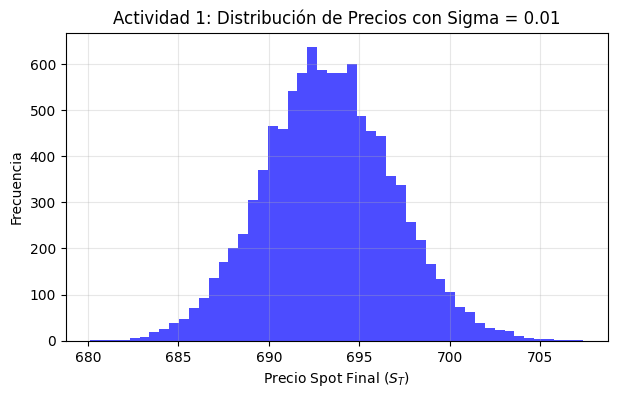

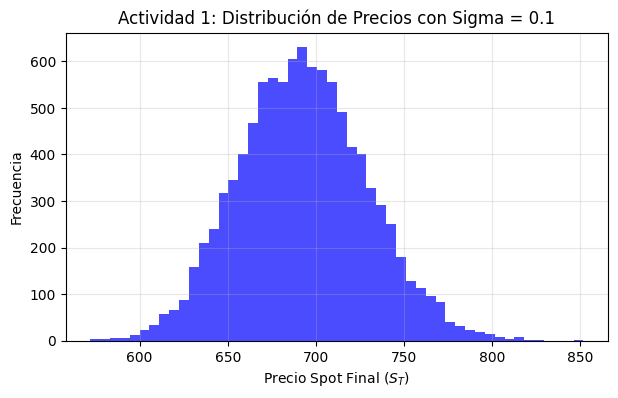

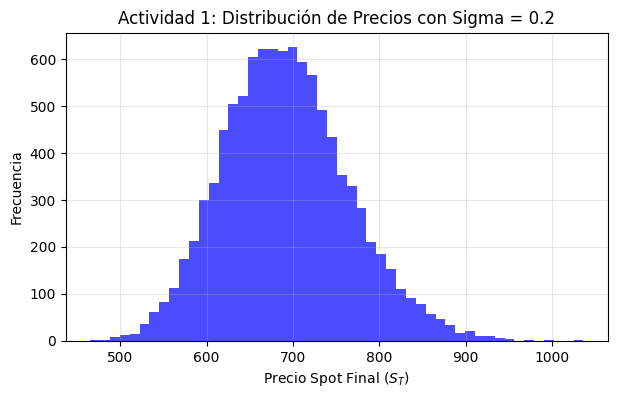

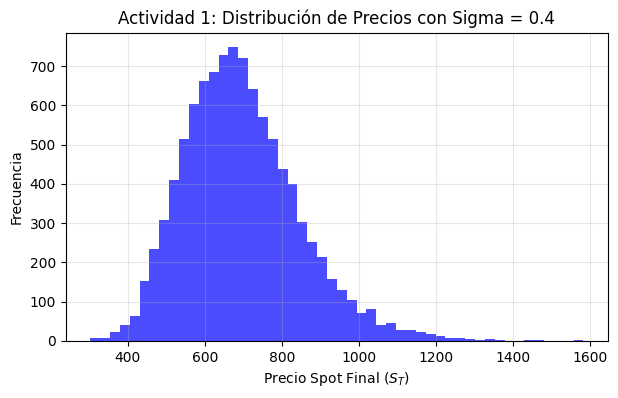

Tabla Actividad 1 - Volatilidad:
        Sigma   Call Value   Put Value
0 0.01000000 110.83181005  0.00000000
1 0.10000000 110.48664407  0.00172151
2 0.20000000 110.65598011  1.20848967
3 0.40000000 126.89711314 14.08053773 



In [7]:
sigmas = [0.01, 0.10, 0.20, 0.40]
resultados_act1 = []

print("Generando gráficas de la Actividad 1...")
for s in sigmas:
    c_val, p_val, St = monte_carlo_sim(S0, K_base, T_base, r_base, s, N)
    resultados_act1.append({'Sigma': s, 'Call Value': c_val, 'Put Value': p_val})
    
    # Crear gráfica individual para cada iteración
    plt.figure(figsize=(7, 4))
    plt.hist(St, bins=50, alpha=0.7, color='blue')
    plt.title(f'Actividad 1: Distribución de Precios con Sigma = {s}')
    plt.xlabel('Precio Spot Final ($S_T$)')
    plt.ylabel('Frecuencia')
    plt.grid(alpha=0.3)
    plt.show()

df_act1 = pd.DataFrame(resultados_act1)
print("Tabla Actividad 1 - Volatilidad:\n", df_act1, "\n")

## Preguntas

- **¿Qué sucede con la dispersión de las trayectorias?** *Respuesta:* Aumenta significativamente. Los precios finales varían mucho más, alcanzando extremos tanto altos como bajos.

- **¿Cómo cambia la distribución de precios?** *Respuesta:* Se va moviendo a la izquierda con colas más largas a la derecha.

- **¿Aumenta o disminuye el valor de la opción conforme aumenta sigma?** *Respuesta:* Aumenta y esto tiene mucha lógica pues a maás volatilidad (riesgo) aumenta el valor de las opciones sin aumentar tu riesgo de pérdida (porque la pérdida máxima está topada a cero).

## Actividad 2:

In [8]:
tiempos = [30/365, 100/365, 1.0] 
etiquetas_T = ['30 días', '100 días', '1 año']
sigma_base = 0.15 
resultados_act2 = []

Generando gráficas de la Actividad 2...


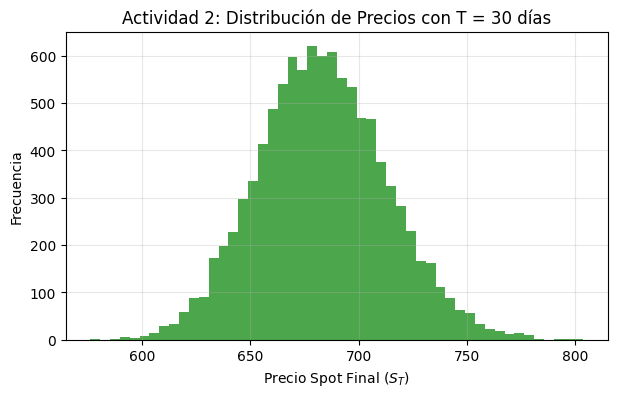

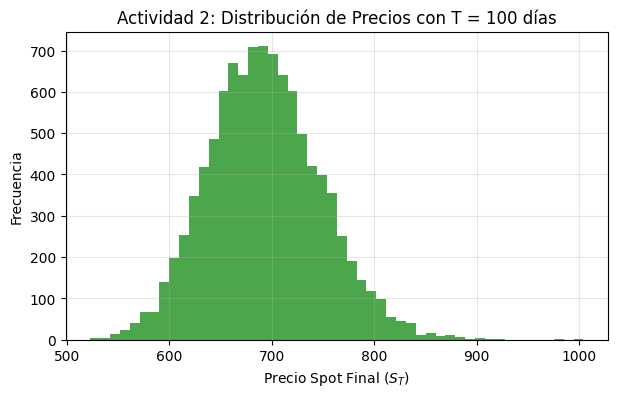

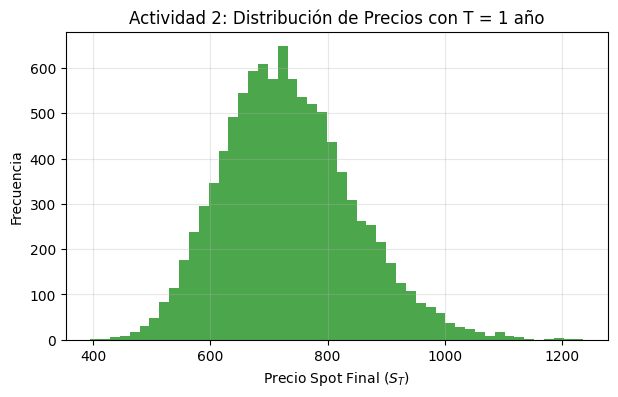

Tabla Actividad 2 - Tiempo al vencimiento:
       Tiempo   Call Value  Put Value
0    30 días 102.16895487 0.00029105
1   100 días 109.61703990 0.17824382
2      1 año 147.24158516 2.16969785
3    30 días 102.11153427 0.00273530
4   100 días 111.81708184 0.20848059
5      1 año 144.93532487 2.17952617
6    30 días 101.76501749 0.00000000
7   100 días 111.40456077 0.19965500
8      1 año 143.76415236 2.18684541
9    30 días 102.47282346 0.00039022
10  100 días 110.96748051 0.20002504
11     1 año 144.15842082 2.43890999 



In [19]:

print("Generando gráficas de la Actividad 2...")
for t, label in zip(tiempos, etiquetas_T):
    c_val, p_val, St = monte_carlo_sim(S0, K_base, t, r_base, sigma_base, N)
    resultados_act2.append({'Tiempo': label, 'Call Value': c_val, 'Put Value': p_val})
    
    # Crear gráfica individual para cada iteración
    plt.figure(figsize=(7, 4))
    plt.hist(St, bins=50, alpha=0.7, color='green')
    plt.title(f'Actividad 2: Distribución de Precios con T = {label}')
    plt.xlabel('Precio Spot Final ($S_T$)')
    plt.ylabel('Frecuencia')
    plt.grid(alpha=0.3)
    plt.show()

df_act2 = pd.DataFrame(resultados_act2)
print("Tabla Actividad 2 - Tiempo al vencimiento:\n", df_act2, "\n")

## Preguntas

- **¿Cómo cambia la distribución final del precio al aumentar T?** *Respuesta:* Se movio otra vez hacia la izquierda y su cola hacia la derecha.

- **¿Aumenta o disminuye el valor de la opción conforme aumenta sigma?** *Respuesta:* Aumenta el valor de la opción como lo dijimos en el caso anterior.

## Actividad 3:

In [21]:
Ks = [S0 * 0.70, S0 * 0.90, S0, S0 * 1.10, S0 * 1.30]
resultados_act3 = []

for k in Ks:
    c_val, p_val, _ = monte_carlo_sim(S0, k, T_base, r_base, sigma_base, N)
    resultados_act3.append({'Strike (K)': k, 'Call Value': c_val, 'Put Value': p_val})

df_act3 = pd.DataFrame(resultados_act3)
print("Tabla Actividad 3 - Precio de Ejercicio (K):\n", df_act3, "\n")

Tabla Actividad 3 - Precio de Ejercicio (K):
     Strike (K)   Call Value    Put Value
0 474.78901367 213.48151313   0.00000000
1 610.44301758  82.83964662   1.05028678
2 678.27001953  29.37759907  14.75855902
3 746.09702148   5.15905786  57.23611837
4 881.75102539   0.01602151 184.72469868 



## Preguntas

- **¿Aumenta o disminuye el valor de la opción conforme aumenta K?** *Respuesta:* Para la Call disminuye pues es más difícil superar la meta. Para la Put aumenta, ya que tienes derecho a vender más caro.

- **¿Qué ocurre cuando el strike es relativamente muy alto? ¿Cuando es muy bajo?** *Respuesta:* Cuando es muy alto La Call casi no vale nada puesto qu es más dificil de alcanzar, mientras que La Put es muy valiosa. Y cuando es muy bajo la Call es muy valiosa porque es casi seguro que ganarás, mientras que la Put casi no vale nada.

## Actividad 4:

Generando gráficas de la Actividad 4...


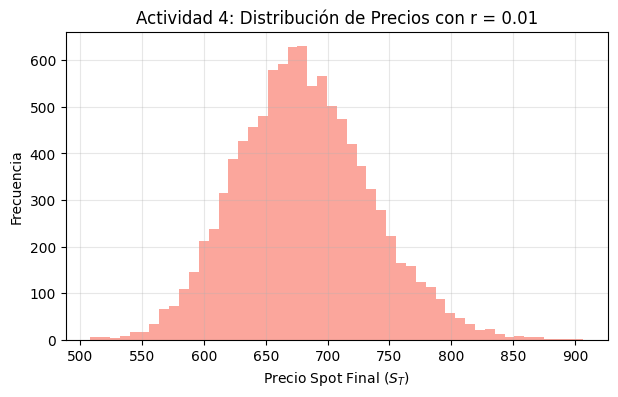

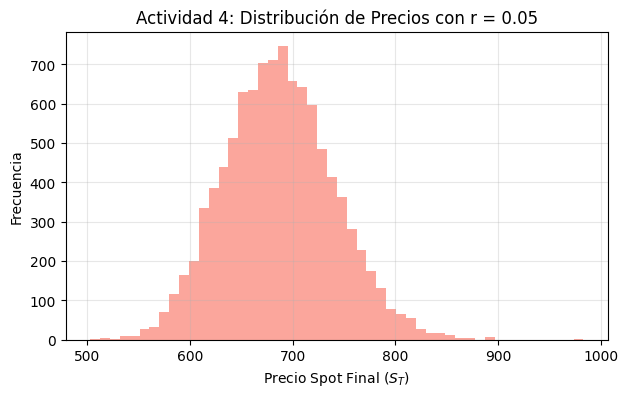

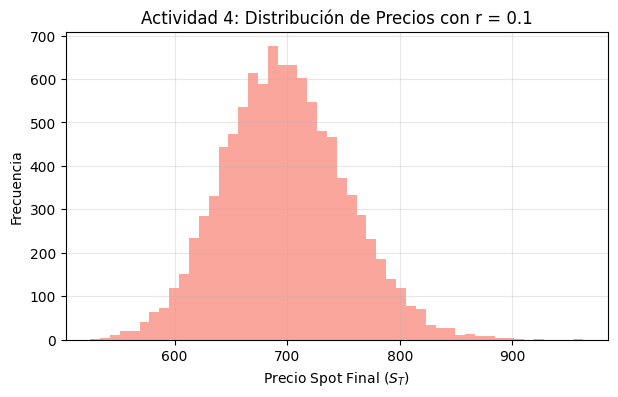

Tabla Actividad 4 - Tasa libre de riesgo:
     Tasa (r)   Call Value  Put Value
0 0.01000000 100.79027772 0.38669681
1 0.05000000 105.69389129 0.26278505
2 0.10000000 115.13780000 0.14993465


In [18]:
tasas = [0.01, 0.05, 0.10]
resultados_act4 = []

print("Generando gráficas de la Actividad 4...")
for r in tasas:
    c_val, p_val, St = monte_carlo_sim(S0, K_base, T_base, r, sigma_base, N)
    resultados_act4.append({'Tasa (r)': r, 'Call Value': c_val, 'Put Value': p_val})
    
    # Crear gráfica individual para cada iteración
    plt.figure(figsize=(7, 4))
    plt.hist(St, bins=50, alpha=0.7, color='salmon')
    plt.title(f'Actividad 4: Distribución de Precios con r = {r}')
    plt.xlabel('Precio Spot Final ($S_T$)')
    plt.ylabel('Frecuencia')
    plt.grid(alpha=0.3)
    plt.show()

df_act4 = pd.DataFrame(resultados_act4)
print("Tabla Actividad 4 - Tasa libre de riesgo:\n", df_act4)

## Preguntas

- **¿Cómo cambia el crecimiento esperado del precio del activo?** *Respuesta:* Aumenta. El modelo asume que, en promedio, el activo crece a la par de la tasa libre de riesgo.

- **¿Qué sucede con el valor de la call cuando aumenta la tasa libre de riesgo?** *Respuesta:* Aumenta, porque se espera que el precio final del activo ($S_T$) sea más alto.

- **¿Qué sucede con el valor de la put cuando aumenta la tasa libre de riesgo?** *Respuesta:* Disminuye, porque al subir el precio esperado del activo, es menos probable que caiga por debajo del precio de ejercicio.